# Online Retail K-means & Hierarchical Clustering

In [5]:
import numpy as np 
import pandas as pd 

df = pd.read_csv("/Users/chauchinh/Downloads/OnlineRetail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [6]:
df.describe(include ='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,31-10-2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [8]:
df.shape

(541909, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
df['CustomerID'].value_counts()

CustomerID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
           ... 
15070.0       1
15753.0       1
17065.0       1
16881.0       1
16995.0       1
Name: count, Length: 4372, dtype: int64

In [11]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
                                       ... 
Missing                                   1
historic computer difference?....se       1
DUSTY PINK CHRISTMAS TREE 30CM            1
WRAP BLUE RUSSIAN FOLKART                 1
PINK BERTIE MOBILE PHONE CHARM            1
Name: count, Length: 4223, dtype: int64

In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df[df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,01-12-2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,01-12-2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,01-12-2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,01-12-2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,09-12-2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,09-12-2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,09-12-2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,09-12-2011 10:26,10.79,NaN,United Kingdom


In [14]:
df[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,01-12-2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,01-12-2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,07-12-2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,07-12-2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,07-12-2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,08-12-2011 10:33,0.0,NaN,United Kingdom


In [15]:
df[df['CustomerID'].isna() & df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,01-12-2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,01-12-2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,07-12-2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,07-12-2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,07-12-2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,08-12-2011 10:33,0.0,NaN,United Kingdom


In [16]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [17]:
# 1. Total Gross Revenue (includes everyone)
total_gross_revenue = df['Revenue'].sum()

# 2. Revenue from Identified Customers (CustomerID is NOT NaN)
identified_revenue = df[df['CustomerID'].notna()]['Revenue'].sum()

# 3. Revenue from "Guest" / Missing IDs
missing_id_revenue = df[df['CustomerID'].isna()]['Revenue'].sum()

print(f"Total Gross Revenue: ${total_gross_revenue:,.2f}")
print(f"Identified Customer Revenue: ${identified_revenue:,.2f}")
print(f"Missing ID Revenue: ${missing_id_revenue:,.2f}")

Total Gross Revenue: $9,747,747.93
Identified Customer Revenue: $8,300,065.81
Missing ID Revenue: $1,447,682.12


In [18]:
percent_missing = (missing_id_revenue / total_gross_revenue) * 100
print(f"Percentage of revenue from missing IDs: {percent_missing:.2f}%")

Percentage of revenue from missing IDs: 14.85%


In [19]:
# Compare total revenue by country for rows with missing IDs
missing_by_country = df[df['CustomerID'].isna()].groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print(missing_by_country.head())

Country
United Kingdom    1419932.97
EIRE                12991.60
Hong Kong           10117.04
Unspecified          2082.72
Israel                913.57
Name: Revenue, dtype: float64


In [20]:
# Top items for missing IDs in the UK
uk_missing = df[(df['Country'] == 'United Kingdom') & (df['CustomerID'].isna())]
top_items_missing = uk_missing.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

print(top_items_missing.head())

Description
CHARLOTTE BAG SUKI DESIGN          9167
POPCORN HOLDER                     5803
RED RETROSPOT CHARLOTTE BAG        4952
WOODLAND CHARLOTTE BAG             4043
PAPER CHAIN KIT 50'S CHRISTMAS     3738
Name: Quantity, dtype: int64


In [21]:
# Check for negative quantities in the missing ID group
cancellations = uk_missing[uk_missing['Quantity'] < 0]
print(f"Number of cancellations with missing IDs: {len(cancellations)}")
print(f"Total value of these cancellations: ${cancellations['Revenue'].sum():,.2f}")

Number of cancellations with missing IDs: 1659
Total value of these cancellations: $-274,773.44


In [22]:
# Look at the biggest individual losses in the missing ID group
big_losses = uk_missing[uk_missing['Quantity'] < 0].sort_values('Revenue').head(10)
print(big_losses[['Description', 'Quantity', 'UnitPrice', 'Revenue']])

       Description  Quantity  UnitPrice   Revenue
524602  AMAZON FEE        -1   17836.46 -17836.46
43702   AMAZON FEE        -1   16888.02 -16888.02
43703   AMAZON FEE        -1   16453.71 -16453.71
15016   AMAZON FEE        -1   13541.33 -13541.33
16356   AMAZON FEE        -1   13541.33 -13541.33
16232   AMAZON FEE        -1   13474.79 -13474.79
524601  AMAZON FEE        -1   11586.50 -11586.50
446533  AMAZON FEE        -1    8286.22  -8286.22
342635  AMAZON FEE        -1    7427.97  -7427.97
191386  AMAZON FEE        -1    7006.83  -7006.83


In [23]:
# Create a mask to exclude Amazon Fees
not_fee = df['Description'] != 'AMAZON FEE'

# New Net Revenue excluding those fees
clean_total_revenue = df[not_fee]['Revenue'].sum()
print(f"Total Revenue (Excluding Amazon Fees): ${clean_total_revenue:,.2f}")

Total Revenue (Excluding Amazon Fees): $9,969,268.43


In [24]:
# List descriptions with the highest total impact (negative or positive) 
# specifically in the missing ID group
non_customer_items = df[df['CustomerID'].isna()].groupby('Description')['Revenue'].sum().sort_values()

print("Top 'Losses' (likely fees/adjustments):")
print(non_customer_items.head(10))

print("\nTop 'Gains' (likely actual sales):")
print(non_customer_items.tail(10))

Top 'Losses' (likely fees/adjustments):
Description
AMAZON FEE                           -221520.50
Adjust bad debt                       -11062.06
Manual                                -10286.18
Bank Charges                           -7340.64
SAMPLES                                -3049.39
POSTAGE                                 -479.60
ASSTD FRUIT+FLOWERS FRIDGE MAGNETS       -66.00
WHITE ALLIUM  ARTIFICIAL FLOWER           -1.69
amazon sales                               0.00
damaged stock                              0.00
Name: Revenue, dtype: float64

Top 'Gains' (likely actual sales):
Description
WHITE SKULL HOT WATER BOTTLE          10366.73
POPCORN HOLDER                        10871.16
RED RETROSPOT CHARLOTTE BAG           11650.94
RABBIT NIGHT LIGHT                    15618.79
HOT WATER BOTTLE TEA AND SYMPATHY     17407.37
CHARLOTTE BAG SUKI DESIGN             22139.30
PAPER CHAIN KIT 50'S CHRISTMAS        22291.46
PARTY BUNTING                         30615.45
REGENCY CAKEST

In [25]:
# 1. Drop rows where CustomerID is missing (crucial for RFM)
rfm_df = df.dropna(subset=['CustomerID']).copy()

# 2. Exclude non-product items (fees, postage) to get 'Pure' Monetary values
admin_items = ['DOTCOM POSTAGE', 'AMAZON FEE', 'POSTAGE', 'Bank Charges', 'Manual', 'Adjust bad debt']
rfm_df = rfm_df[~rfm_df['Description'].isin(admin_items)]

# 3. Ensure InvoiceDate is in datetime format
# Fix the date conversion
rfm_df['InvoiceDate'] = pd.to_datetime(rfm_df['InvoiceDate'], dayfirst=True)

In [26]:
import datetime as dt

# Set snapshot date
snapshot_date = rfm_df['InvoiceDate'].max() + dt.timedelta(days=1)

# Aggregate data by CustomerID
rfm = rfm_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'Revenue': 'sum'                                         # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [28]:
print(f"Data starts: {rfm_df['InvoiceDate'].min()}")
print(f"Data ends:   {rfm_df['InvoiceDate'].max()}")

Data starts: 2010-12-01 08:26:00
Data ends:   2011-12-09 12:50:00


In [29]:
# 1. Create quintile labels
r_labels = range(5, 0, -1) # 5 is most recent, 1 is least recent
f_labels = range(1, 6)    # 5 is highest frequency
m_labels = range(1, 6)    # 5 is highest spend

# 2. Assign scores to 5 groups
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

# 3. Concatenate scores into a single string for segmenting
rfm['RFM_Group'] = rfm.R.astype(str) + rfm.F.astype(str) + rfm.M.astype(str)

# 4. Calculate a total RFM Score (numeric sum)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)
rfm

,Recency,Frequency,Monetary,R,F,M,RFM_Group,RFM_Score
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,2,1,121,4
12347.0,2,7,4310.00,5,4,5,545,14
12348.0,75,4,1437.24,2,4,4,244,10
12349.0,19,1,1457.55,4,1,4,414,9
12350.0,310,1,294.40,1,1,2,112,4
...,...,...,...,...,...,...,...,...
18280.0,278,1,180.60,1,2,1,121,4
18281.0,181,1,80.82,1,2,1,121,4
18282.0,8,3,176.60,5,4,1,541,10


In [34]:
def segment_me(df):
    if df['RFM_Score'] >= 14:
        return 'Champions'
    elif (df['RFM_Score'] >= 11) and (df['RFM_Score'] < 14):
        return 'Loyal Customers'
    elif (df['RFM_Score'] >= 8) and (df['RFM_Score'] < 11):
        return 'Potential Loyalist'
    elif (df['RFM_Score'] >= 5) and (df['RFM_Score'] < 8):
        return 'At Risk / Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_me, axis=1)
segment_counts = rfm['Segment'].value_counts()
segment_counts

Segment
At Risk / Hibernating    1168
Potential Loyalist       1045
Loyal Customers           970
Champions                 648
Lost                      532
Name: count, dtype: int64

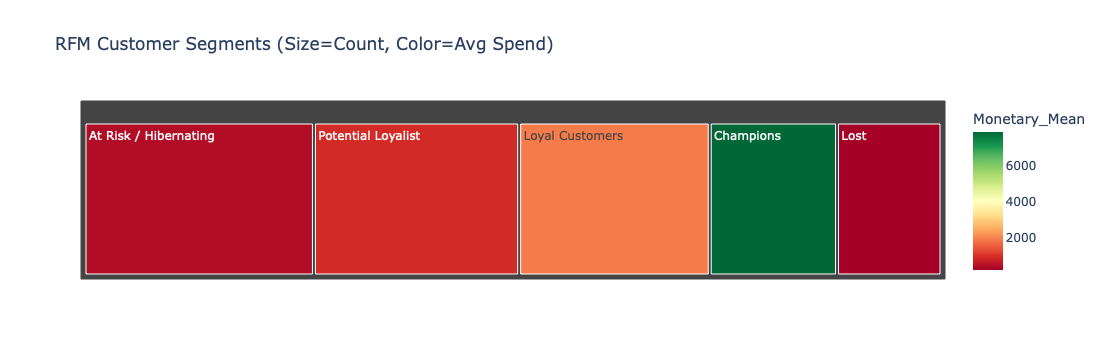

In [35]:
import plotly.express as px

# Prepare data for visualization
rfm_stats = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

rfm_stats.columns = ['Recency_Mean', 'Frequency_Mean', 'Monetary_Mean', 'Count']
rfm_stats = rfm_stats.reset_index()

# Plot
fig = px.treemap(rfm_stats, 
                 path=['Segment'], 
                 values='Count',
                 color='Monetary_Mean',
                 title='RFM Customer Segments (Size=Count, Color=Avg Spend)',
                 color_continuous_scale='RdYlGn')
fig.show()

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# 1. Handle 0 or negative values (log only works on positive numbers)
rfm_nonzero = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_nonzero[rfm_nonzero <= 0] = 1 

# 2. Log Transform to handle skewness
rfm_log = np.log(rfm_nonzero)

# 3. Scale the data (Mean=0, Std=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Create a DataFrame for the scaled data
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=['Recency', 'Frequency', 'Monetary'])

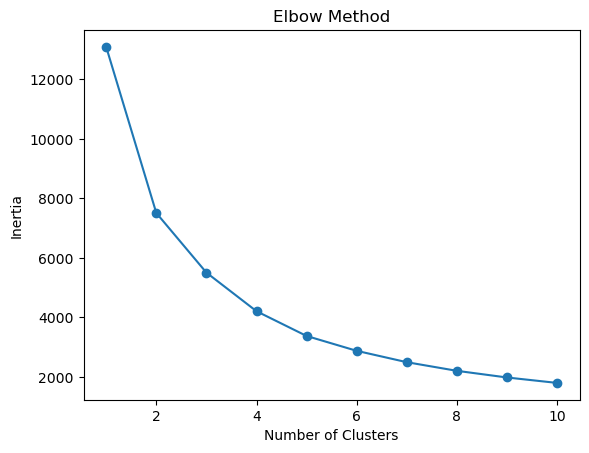

In [37]:
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [38]:
# 1. Initialize and fit the model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled) # Use the scaled data from before

# 2. View the characteristics of each cluster
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print(cluster_summary)

        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0          23.8       9.7   3964.5  1766
1         138.8       1.8    493.2  2592
2          67.0       2.0      0.0     5


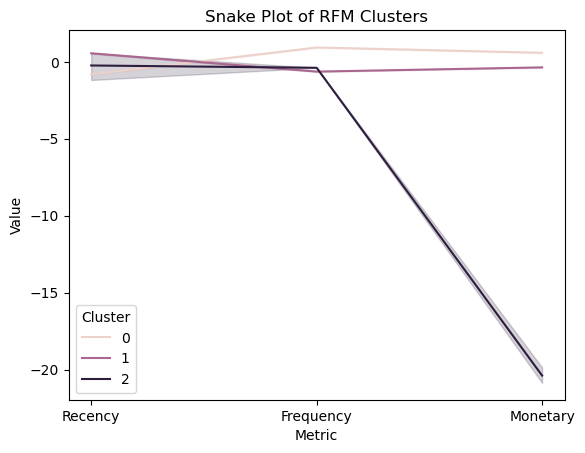

In [39]:
import seaborn as sns

# Prepare data for Snake Plot
rfm_scaled_df['Cluster'] = rfm['Cluster']
rfm_melted = pd.melt(rfm_scaled_df.reset_index(), 
                    id_vars=['CustomerID', 'Cluster'],
                    value_vars=['Recency', 'Frequency', 'Monetary'], 
                    var_name='Metric', 
                    value_name='Value')

# Plot
plt.title('Snake Plot of RFM Clusters')
sns.lineplot(x='Metric', y='Value', hue='Cluster', data=rfm_melted)
plt.show()

In [40]:
# Create a mapping based on your specific results
cluster_map = {
    0: 'VIP Customers',
    1: 'At Risk / Churned',
    2: 'Anomalies/Zero-Value'
}

rfm['Segment_KMeans'] = rfm['Cluster'].map(cluster_map)

# View the final result distribution
print(rfm['Segment_KMeans'].value_counts())

Segment_KMeans
At Risk / Churned       2592
VIP Customers           1766
Anomalies/Zero-Value       5
Name: count, dtype: int64


In [41]:
# 1. Initialize and fit the model with k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster_4'] = kmeans_4.fit_predict(rfm_scaled)

# 2. View the characteristics of each cluster
cluster_4_summary = rfm.groupby('Cluster_4').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Sort by Monetary to make interpretation easier
print(cluster_4_summary.sort_values(('Monetary', 'mean'), ascending=False))

          Recency Frequency Monetary      
             mean      mean     mean count
Cluster_4                                 
1            10.4      15.3   6838.1   794
0            48.8       4.2   1278.9  1693
2           166.1       1.4    366.1  1871
3            67.0       2.0      0.0     5


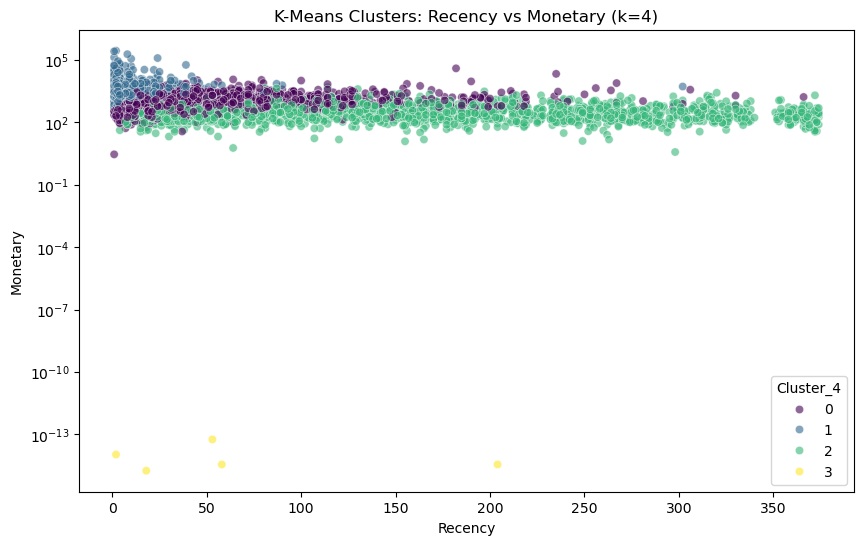

In [42]:
import seaborn as sns

# Plotting the 4 clusters across Recency vs Monetary
plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster_4', palette='viridis', alpha=0.6)
plt.yscale('log') # Log scale helps see the distribution clearly
plt.title('K-Means Clusters: Recency vs Monetary (k=4)')
plt.show()

In [43]:
# Identify the 5 anomalies
anomalies = rfm[rfm['Cluster_4'] == 3]
print(anomalies)

            Recency  Frequency      Monetary  R  F  M RFM_Group  RFM_Score  \
CustomerID                                                                   
12454.0          53          2  5.684342e-14  3  2  1       321          6   
12558.0           2          2  1.065814e-14  5  2  1       521          8   
12607.0          58          2  3.552714e-15  3  2  1       321          6   
13762.0         204          2  3.552714e-15  1  2  1       121          4   
18274.0          18          2  1.776357e-15  4  3  1       431          8   

                          Segment  Cluster        Segment_KMeans  Cluster_4  
CustomerID                                                                   
12454.0     At Risk / Hibernating        2  Anomalies/Zero-Value          3  
12558.0        Potential Loyalist        2  Anomalies/Zero-Value          3  
12607.0     At Risk / Hibernating        2  Anomalies/Zero-Value          3  
13762.0                      Lost        2  Anomalies/Zero-Valu

In [44]:
# Look at the raw transaction history for these specific IDs
anomaly_ids = [12454.0, 12558.0, 12607.0, 13762.0, 18274.0]
anomaly_history = df[df['CustomerID'].isin(anomaly_ids)]

# Display their InvoiceNo, Quantity, and Revenue
print(anomaly_history[['CustomerID', 'InvoiceNo', 'Description', 'Quantity', 'Revenue']])

        CustomerID InvoiceNo                          Description  Quantity  \
175118     13762.0    551883          HANGING METAL HEART LANTERN        72   
175119     13762.0    551883   MINI CAKE STAND  HANGING STRAWBERY         8   
175120     13762.0    551883       STRAWBERRY CERAMIC TRINKET BOX        24   
175121     13762.0    551883  KNICKERBOCKERGLORY MAGNET ASSORTED         96   
175122     13762.0    551883       SWEETHEART CERAMIC TRINKET BOX        24   
...            ...       ...                                  ...       ...   
536922     12558.0   C581229          SET OF 5 LUCKY CAT MAGNETS        -36   
536923     12558.0   C581229                     CARD DOLLY GIRL        -12   
536924     12558.0   C581229              TEA PARTY BIRTHDAY CARD       -12   
536925     12558.0   C581229              VINTAGE KID DOLLY CARD        -12   
536926     12558.0   C581229              ELEPHANT BIRTHDAY CARD        -12   

        Revenue  
175118   104.40  
175119    13.20

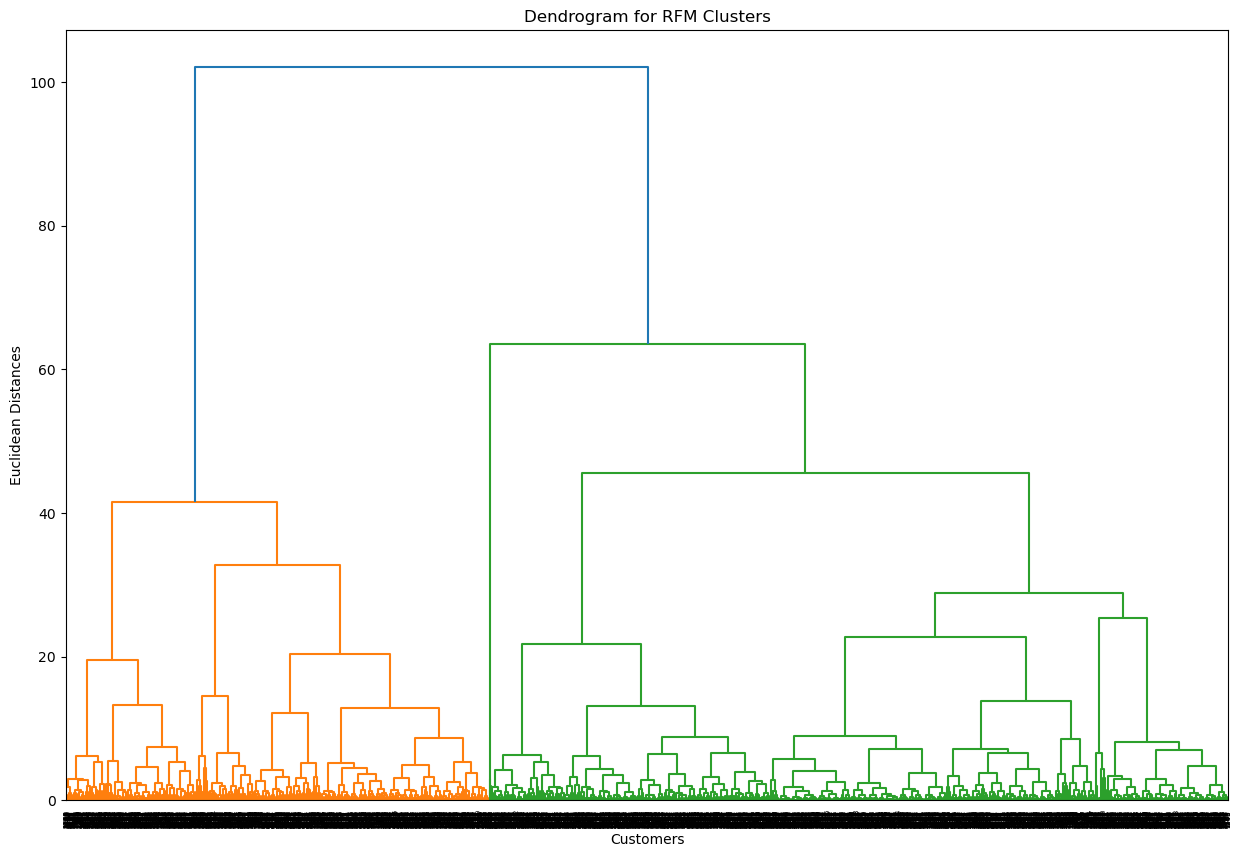

In [45]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# 1. Create the Linkage Matrix using Ward's Method
# Ward's method minimizes the variance within clusters
linkage_matrix = sch.linkage(rfm_scaled, method='ward')

# 2. Plot the Dendrogram
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(linkage_matrix)
plt.title('Dendrogram for RFM Clusters')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

In [46]:
# 3. Fit the Agglomerative Clustering model
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
rfm['Cluster_HC'] = hc.fit_predict(rfm_scaled)

# 4. View the results
hc_summary = rfm.groupby('Cluster_HC').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print(hc_summary.sort_values(('Monetary', 'mean'), ascending=False))

           Recency Frequency Monetary      
              mean      mean     mean count
Cluster_HC                                 
0             15.4       9.9   4106.7  1591
3             68.3       3.6    934.3  1049
1            177.9       1.4    445.7  1718
2             67.0       2.0      0.0     5


In [47]:
# Compare the two models
comparison = pd.crosstab(rfm['Cluster_4'], rfm['Cluster_HC'])
print("K-Means (Rows) vs. Hierarchical (Columns)")
print(comparison)

K-Means (Rows) vs. Hierarchical (Columns)
Cluster_HC    0     1  2    3
Cluster_4                    
0           765    51  0  877
1           793     0  0    1
2            33  1667  0  171
3             0     0  5    0


In [48]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Group,RFM_Score,Segment,Cluster,Segment_KMeans,Cluster_4,Cluster_HC
CustomerID,,,,,,,,,,,,,
12346.0,326,2,0.00,1,2,1,121,4,Lost,1,At Risk / Churned,2,1
12347.0,2,7,4310.00,5,4,5,545,14,Champions,0,VIP Customers,1,0
12348.0,75,4,1437.24,2,4,4,244,10,Potential Loyalist,1,At Risk / Churned,0,3
12349.0,19,1,1457.55,4,1,4,414,9,Potential Loyalist,1,At Risk / Churned,0,1
12350.0,310,1,294.40,1,1,2,112,4,Lost,1,At Risk / Churned,2,1


In [50]:
# Create the final targeting column
rfm['Final_Target'] = 'Other'
rfm.loc[(rfm['Cluster_4'] == 1) & (rfm['Cluster_HC'] == 0), 'Final_Target'] = 'Platinum VIP'
rfm.loc[(rfm['Cluster_4'] == 0) & (rfm['Cluster_HC'] == 0), 'Final_Target'] = 'Gold Regular'
rfm.loc[(rfm['Cluster_4'] == 0) & (rfm['Cluster_HC'] == 3), 'Final_Target'] = 'Silver Prospect'
rfm.loc[(rfm['Cluster_4'] == 2) & (rfm['Cluster_HC'] == 1), 'Final_Target'] = 'Bronze Churned'

rfm[rfm['Final_Target']=='Other'].count()

Recency           261
Frequency         261
Monetary          261
R                 261
F                 261
M                 261
RFM_Group         261
RFM_Score         261
Segment           261
Cluster           261
Segment_KMeans    261
Cluster_4         261
Cluster_HC        261
Final_Target      261
dtype: int64

In [51]:
# 1. Group by the final target and calculate key metrics
summary_stats = rfm.groupby('Final_Target').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum', 'count']
}).round(2)

# 2. Flatten the multi-index columns for easier reading
summary_stats.columns = ['Recency_Avg', 'Freq_Avg', 'Revenue_Avg', 'Total_Revenue', 'Customer_Count']

# 3. Calculate the % of total revenue each segment contributes
total_rev = summary_stats['Total_Revenue'].sum()
summary_stats['Revenue_Share_%'] = (summary_stats['Total_Revenue'] / total_rev * 100).round(2)

# 4. Sort by the highest average value
print(summary_stats.sort_values('Revenue_Avg', ascending=False))

                 Recency_Avg  Freq_Avg  Revenue_Avg  Total_Revenue  \
Final_Target                                                         
Platinum VIP           10.07     15.32      6840.03     5424143.31   
Gold Regular           21.04      4.64      1440.37     1101883.68   
Silver Prospect        65.92      3.80      1032.85      905813.78   
Other                  89.58      2.39       917.78      239540.24   
Bronze Churned        178.04      1.33       364.90      608288.66   

                 Customer_Count  Revenue_Share_%  
Final_Target                                      
Platinum VIP                793            65.51  
Gold Regular                765            13.31  
Silver Prospect             877            10.94  
Other                       261             2.89  
Bronze Churned             1667             7.35  


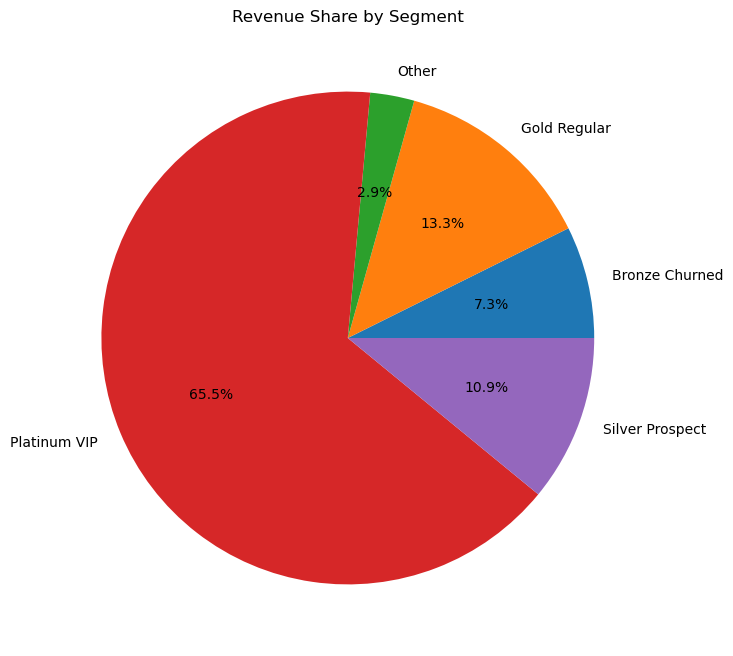

In [52]:
import matplotlib.pyplot as plt

summary_stats['Total_Revenue'].plot(kind='pie', autopct='%1.1f%%', figsize=(8,8), title='Revenue Share by Segment')
plt.ylabel('')
plt.show()